In [3]:
import os
import matplotlib.pylab as plt
import stpsf
import numpy as np
import matplotlib
import pandas as pd


# Roman Wavefront Model in STPSF

[SCIPA (Spacecraft + Integrated Payload Assembly) TVAC](https://roman-docs.stsci.edu/roman-instruments/the-wide-field-instrument/wfi-characterization-activities/wfi-ground-testing-campaigns#WFIGroundTestingCampaigns-SCIPA)  was the final end-to-end performance test of the Roman WFI, conducted at NASA Goddard from August–October 2025. It was the final time the WFI operated at flight-like temperatures before launch.

## A compact parametric representation of the post-SCIPA wavefront model


This notebook documents the methodology used to incorporate the latest Roman Wide Field Instrument (WFI) optical model into STPSF.

NASA's post-SCIPA optical model delivery provides substantially denser field sampling across each detector, including a 5×5 grid of field positions. Representing all of these optical maps directly, however, would significantly increase the size of the STPSF reference-data package.

We therefore developed a compact wavefront representation based on two components:

1. Field-dependent Zernike coefficients through Z210, which describe the spatially varying low- and intermediate-spatial-frequency wavefront structure.
2. A detector-specific high-frequency residual map, which preserves spatial structure that is not efficiently represented by the Zernike expansion.

This representation allows STPSF to retain the additional field information provided by the post-SCIPA model while keeping the reference-data package practical for distribution and use.

> **Key Result**
>
> The new STPSF implementation increases the field sampling from 5 field positions to 25 field positions (5×5) per detector.
The compact Zernike + high-frequency representation reconstructs the original post-SCIPA wavefront maps with an RMS residual of approximately 12 nm.

## Methodology Schematic


<img src="./roman_figures/data_diagram.png"
     alt="Phase Map Decomposition"
     width="1400">

**Caption**

*STPSF - Roman Post-SCIPA Methodology Schematic*

## Post-SCIPA Optical Delivery

Historically, Roman STPSF releases contained optical information at only five field positions per detector.

The post-SCIPA delivery introduced:

- 25 field points per detector.
- Full wavefront maps at each field location.
- Eight WFI imaging filters.
- Prism and grism modes.

The new 5×5 sampling pattern provides significantly improved characterization of field-dependent aberrations across the focal plane.

## Data Volume Challenge

For every detector, filter, and field position, the optical delivery contains a complete phase map.

$$
N_{maps} = N_{detector} \times N_{filter} \times 25
$$

Storing these phase maps directly would substantially increase the size of the STPSF data distribution.

A compression strategy was therefore developed that preserves optical realism while maintaining a manageable data package.

## Model-based representation

After removing a global piston term, each phase map is represented as a Zernike expansion:

$$
W(\rho,\theta)=\sum_{i=1}^{210} a_i Z_i(\rho,\theta)+R(\rho,\theta)
$$

where:

- $a_i$ are the fitted coefficients,
- $Z_i$ are Zernike polynomials,
- $R$ is the residual phase map.

Each post-SCIPA wavefront map is decomposed into a Zernike representation through Z210 and a residual map. The Zernike coefficients capture the low- and intermediate-spatial-frequency structure of the wavefront, while the residual contains structure that is not efficiently represented by the finite Zernike basis.

## Figure 1 — Phase Map Decomposition


<img src="./roman_figures/comparison_phase_maps.png"
     alt="Phase Map Decomposition"
     width="1000">

**Caption**

*Example decomposition of a post-SCIPA phase map. Left: original wavefront map. Center: reconstruction using Zernike terms through Z210. Right: residual after subtraction. The residual contains primarily high-spatial-frequency structure that is not efficiently represented by the Zernike basis.*

Inspection of the decomposition demonstrates that the majority of the optical power is captured by the Zernike representation. The remaining structure primarily consists of detector-scale high-frequency structure that is not efficiently represented by the finite Zernike basis.

## Choosing the Zernike Order

The number of retained Zernike coefficients determines the trade-off between reconstruction accuracy and data volume.

Increasing the Zernike order progressively reduces the reconstruction residual. At sufficiently high orders, however, the improvement becomes increasingly small because the remaining error is dominated by high-spatial-frequency structure.

The convergence study shows that Z210 provides a useful balance between reconstruction accuracy and data volume and was therefore selected for the STPSF implementation.

## Figure 2 — Reconstruction Performance Versus Zernike Order

Insert:


<img src="./roman_figures/zernike_numbers.png"
     alt="Zernike Terms"
     width="600">

**Caption**

*Wavefront reconstruction fidelity as a function of Zernike order. The residual RMS decreases rapidly at low orders and asymptotically approaches a floor set by high-frequency structure. Beyond approximately Z210 the improvements become modest, motivating the adoption of Z210 for operational use within STPSF.*

The convergence study demonstrated that Z210 provides an effective compromise between accuracy and storage requirements while maintaining excellent agreement with the original phase maps.

## Multiwavelength Optical Behavior

Goddard optical delivery phase maps for the 5x5 grid are at the center wavelength of each filter. However, multiwavelength information in the form of a modest Zernike expansion of 45 terms was provided for a  smaller 5-point grid. Therefore to capture broadband information for the larger 5x5 grid we needed  to estimate the Zernike expansion at different wavelengths inside the filter. The wavelength dependence was first investigated using the wavelength-dependent 5-field-point optical delivery. This analysis showed that, within each filter, the fitted Zernike coefficients are approximately wavelength-independent, with defocus (Z4) being the dominant exception.

$$
a_i(\lambda) \approx constant \qquad i \ne 4
$$

This property enables efficient modeling of wavelength dependence without storing a complete set of coefficients for every wavelength.

## Defocus Modeling

We therefore model the wavelength dependence of Z4 separately while treating the remaining coefficients as effectively constant within each filter.

For each wavelength sample, a two-dimensional plane was fit across the full 5×5 field grid.

This approach enables interpolation of defocus throughout the bandpass while preserving the original field dependence.

**Validation**

Predicted values agree with the original optical delivery at approximately the one percent level.

**Figure 3 — Multiwavelength defocus (Z4) defocus fit across the full 5x5 grid**

<img src="./roman_figures/zernike_defocus.png"
     alt="Zernike Terms"
     width="1000">

**Caption**

*Example of the Zernike focus coefficient prediction at the shortest wavelength range for the WFI F620 filter across the full 5x5 grid based on our fit of a two-dimensional plane of the 5-point grid sampling*

## High-Frequency Residual Maps

After reconstruction through Z210, the residual map is defined as:

$$
HF = W_{SCIPA} - W_{Z210}
$$

Inspection of these residuals revealed:

- Minimal wavelength dependence.
- Strong detector dependence.
- Consistent spatial structure across filters.

Examination of the residual maps showed that the high-frequency structure is primarily detector-dependent and exhibits relatively little wavelength or filter dependence. The spatial pattern is also stable across the available field positions. This suggests that the residual can be represented efficiently by a single detector-specific high-frequency map.

## Detector-Averaged High-Frequency Maps

A mean residual map was computed for every detector:

$$
HF_d = \frac{1}{N_\lambda} \sum_{\lambda} HF_{d,\lambda}
$$

The resulting map captures the detector-dependent high-spatial-frequency structure and can be reused across filters.

This reduces the amount of high-frequency information that must be stored while preserving the dominant detector-specific structure identified in the post-SCIPA delivery.

**Figure 4 — Example High-Frequency Detector Map**

<img src="./roman_figures/high-frequency_maps.png"
     alt="Zernike Terms"
     width="1000">

**Caption**

*Detector-averaged high-frequency residual map. The residual structure is dominated by detector-dependent features and exhibits minimal wavelength dependence, supporting the use of a single correction map for each detector.*

## Final Multi-Field Phase Maps

The final STPSF wavefront model combines:

- detector and field-dependent Zernike coefficients through Z210,
- wavelength-dependent modeling of Z4,
- one detector-specific high-frequency residual map, and
- 25 field positions arranged on a 5×5 grid for each detector.

Together, these components provide a compact representation of the post-SCIPA optical model for use in STPSF.

(-694.2237991854523, 1089.7937194350322)

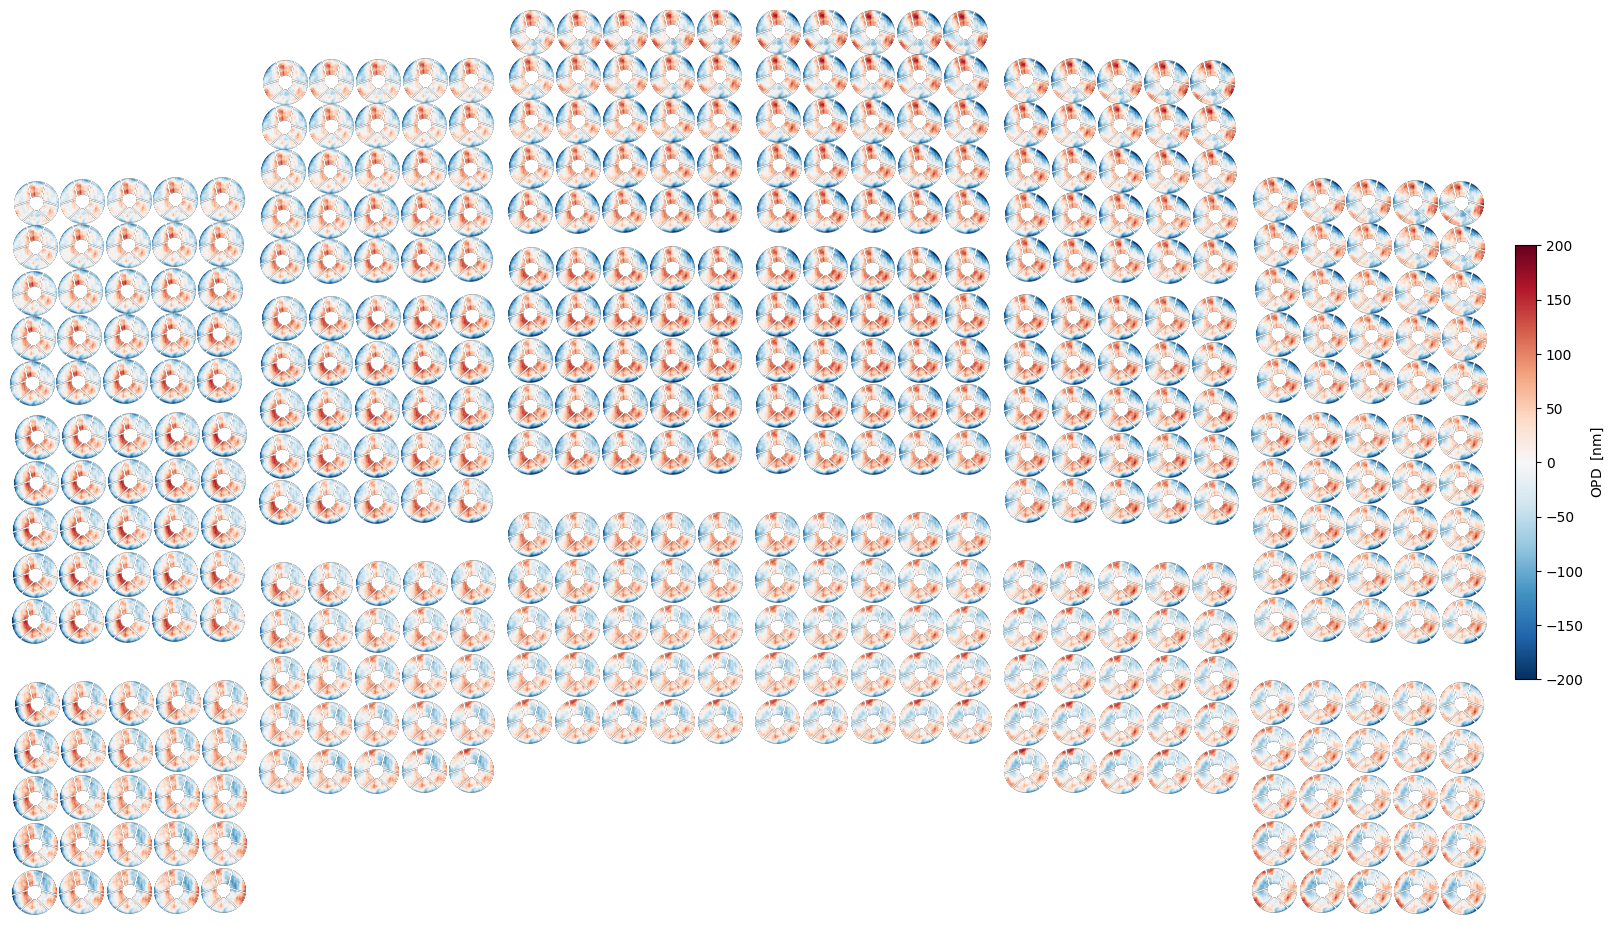

In [4]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import stpsf

wfi = stpsf.WFI()
stpsf.roman._log.setLevel(40)

wfi.filter = 'F062'
wavelength = 0.62e-6

cmap = mpl.colormaps.get_cmap('RdBu_r')
norm = mpl.colors.Normalize(-200,200)

wficen = wfi.siaf['WFI_CEN']

aper = wfi.siaf[wfi.aperturename]
npad = aper.XSciSize/12
xsci_samples = ysci_samples = np.linspace(1+npad, aper.XSciSize+1-npad, 5)
xysci_grid = np.array([cgrid.flatten() for cgrid in np.meshgrid(xsci_samples, ysci_samples)]).T

ext_halfwidth = (aper.XSciSize/5)*wfi.pixelscale/2

fig,ax = plt.subplots(figsize=(18,15))

R = np.array([[np.cos(np.deg2rad(-60)), -np.sin(np.deg2rad(-60))],
              [np.sin(np.deg2rad(-60)),  np.cos(np.deg2rad(-60))]]) # Rot matrix for tel to sci orientation

extents = []
for sca in np.arange(1,19):
    wfi.detector = f'WFI{sca:02d}'
    aper = wfi.siaf[wfi.aperturename]
    for fov in np.arange(1,26):
        xysci = xysci_grid[fov-1]
        xytel = np.array(aper.sci_to_tel(*xysci))
        xyan = R @ np.array([xytel[0]-wficen.V2Ref, xytel[1]-wficen.V3Ref])

        wfi.detector_position = xysci

        # Construct the optical system
        osys = wfi.get_optical_system()

        # Construct a pupil wavefront
        wave = osys.input_wavefront(wavelength=wavelength)

        # First plane = pupil transmission + high-frequency OPD
        entrance_pupil = osys.planes[0]

        # Find the field-dependent Zernike optic
        zernike_optic = next(plane for plane in osys.planes
                             if isinstance(plane,stpsf.roman.FieldDependentAberration))

        opd_highfreq = entrance_pupil.get_opd(wave)*1e9
        opd_zernike = zernike_optic.get_opd(wave)*1e9

        opd_highfreq = np.where(opd_highfreq == 0, np.nan, opd_highfreq)
        opd_zernike = np.where(opd_zernike == 0, np.nan, opd_zernike)

        opd_total = opd_zernike + opd_highfreq

        extent = (-xyan[:,None] + np.array([-ext_halfwidth, ext_halfwidth])[None]).ravel()
        extents.append(extent)

        ax.imshow(opd_total, origin='lower', extent=extent, norm=norm, cmap=cmap)

fig.tight_layout()

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm, cmap),
                    ax=ax,
                    label='${\\rm OPD \\;\\; [nm]}$',
                    shrink=0.3,
                    pad=0.015)

[ax.spines[key].set_edgecolor('None') for key in ax.spines]
ax.set(xticks=[], yticks=[])

ax.set_xlim(np.percentile(np.array(extents)[..., :2], [0,100]))
ax.set_ylim(np.percentile(np.array(extents)[..., 2:], [0,100]))